# SE446 — Milestone 2: Chicago Crime Analytics with Spark + MLlib

**Course:** SE446 — Big Data Engineering
**Group:** Shh
**Milestone:** 2 — Spark DataFrames + MLlib

| Member | ID | GitHub | Tasks |
|---|---|---|---|
| Sarah Alomar | 231283 | smalomar | 1, 2, 11 |
| Haifa Alrayes  | 231171 | haifafr | 3, 4, 9, 10 |
| Haifa Binhethlen   | 231265 | haifabh    | 5, 6, 7, 8 |

The notebook auto-detects environment (local laptop / Hadoop cluster). On the cluster
it reads `hdfs:///data/chicago_crimes.csv` (793,073 records); locally it uses the
in-memory generator from the W09B lab (10,000 rows).


## Part 0: Environment Setup

In [1]:
import os, sys, shutil, subprocess, time

IN_COLAB = "google.colab" in sys.modules

def detect_environment():
    if IN_COLAB:
        return "colab"
    # Cluster heuristic: hdfs binary present on PATH
    if shutil.which("hdfs") is not None:
        return "cluster"
    return "local"

ENV = detect_environment()
print(f"Environment detected: {ENV.upper()}")


Environment detected: LOCAL


In [2]:
from pyspark.sql import SparkSession

# Build a SparkSession that respects spark-submit's --master flag when present.
# Locally (no spark-submit), default to local[*].
builder = (SparkSession.builder
           .appName("SE446_M2_GroupShh")
           .config("spark.sql.shuffle.partitions", "4"))

if ENV != "cluster":
    builder = (builder
               .master("local[*]")
               .config("spark.driver.memory", "2g"))

spark = builder.getOrCreate()
if ENV != "cluster":
    spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")


26/05/02 20:12:20 WARN Utils: Your hostname, Rahuls-iMac.local resolves to a loopback address: 127.0.0.1; using 10.101.97.185 instead (on interface en1)
26/05/02 20:12:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/02 20:12:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/05/02 20:12:28 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 3.5.1
Master: local[*]


## Load Data

On the cluster: read the real CSV from HDFS. Locally: use the W09B in-memory
generator extended with `Year` and `Location Description` so Phase A has columns
to group by.

In [3]:
from pyspark.sql.functions import col, hour, to_timestamp, year as spark_year

if ENV == "cluster":
    raw_df = spark.read.csv(
        "hdfs:///data/chicago_crimes.csv",
        header=True, inferSchema=True
    )
    df = raw_df.withColumn(
        "Hour", hour(to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))
    )
    df = df.withColumn("label", col("Arrest").cast("integer"))
    df.cache()

else:
    from pyspark.sql import Row
    import random
    random.seed(42)

    crime_profiles = {
        "NARCOTICS":           0.85,
        "PROSTITUTION":        0.80,
        "WEAPONS VIOLATION":   0.60,
        "BATTERY":             0.30,
        "ASSAULT":             0.25,
        "ROBBERY":             0.15,
        "THEFT":               0.10,
        "BURGLARY":            0.08,
        "MOTOR VEHICLE THEFT": 0.06,
        "CRIMINAL DAMAGE":     0.05,
    }
    locations = [
        "STREET","RESIDENCE","APARTMENT","SIDEWALK","OTHER",
        "PARKING LOT/GARAGE(NON.RESID.)","SCHOOL","ALLEY",
        "RESIDENCE-GARAGE","SMALL RETAIL STORE","RESTAURANT","DEPARTMENT STORE",
    ]
    location_weights = [0.31,0.17,0.08,0.06,0.04,0.03,0.03,0.025,0.02,0.018,0.015,0.012]
    years = [2020, 2021, 2022, 2023, 2024, 2025]
    year_weights = [0.05, 0.06, 0.10, 0.40, 0.25, 0.14]

    districts = list(range(1, 26))

    def generate_row():
        crime_type = random.choice(list(crime_profiles.keys()))
        base_rate = crime_profiles[crime_type]
        district = random.choice(districts)
        hour_val = random.randint(0, 23)
        domestic = random.random() < 0.15
        arrest_prob = base_rate + (0.20 if domestic else 0)
        if 2 <= hour_val <= 5:
            arrest_prob -= 0.10
        arrest_prob = max(0.01, min(0.99, arrest_prob))
        arrest = random.random() < arrest_prob
        loc = random.choices(locations, weights=location_weights, k=1)[0]
        yr = random.choices(years, weights=year_weights, k=1)[0]
        return Row(
            District=district,
            **{"Primary Type": crime_type},
            **{"Location Description": loc},
            Year=yr,
            Hour=hour_val,
            Domestic=domestic,
            Domestic_str=str(domestic).lower(),
            Arrest=arrest,
            label=int(arrest),
        )

    rows = [generate_row() for _ in range(10000)]
    df = spark.createDataFrame(rows)
    df.cache()

print(f"Dataset: {df.count():,} rows")
df.printSchema()
df.show(3)


Dataset: 10,000 rows
root
 |-- District: long (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)



+--------+-------------------+--------------------+----+----+--------+------------+------+-----+
|District|       Primary Type|Location Description|Year|Hour|Domestic|Domestic_str|Arrest|label|
+--------+-------------------+--------------------+----+----+--------+------------+------+-----+
|       1|       PROSTITUTION|            SIDEWALK|2024|  23|   false|       false|  true|    1|
|       3|MOTOR VEHICLE THEFT|              STREET|2023|  18|   false|       false|  true|    1|
|      18|          NARCOTICS|           RESIDENCE|2023|   6|   false|       false|  true|    1|
+--------+-------------------+--------------------+----+----+--------+------------+------+-----+
only showing top 3 rows



---
# Phase A — Spark DataFrame Analytics
*Reproducing M1 MapReduce analyses with Spark.*

## Task 1: Crime Type Distribution (Spark DataFrame)

**Author: Sarah Alomar (ID: 231283)**

> **Research Question:** What are the most common types of crimes in Chicago?

Same question as M1 Task 2, now using Spark DataFrames instead of mapper/reducer scripts.

In [4]:
# ============================================
# Task 1: Crime Type Distribution (DataFrame)
# Author: Sarah Alomar (ID: 231283)
# ============================================
from pyspark.sql.functions import col

print("Top 10 crime types:")
top_crimes = df.groupBy("Primary Type").count().orderBy(col("count").desc())
top_crimes.show(10, truncate=False)


Top 10 crime types:


+-------------------+-----+
|Primary Type       |count|
+-------------------+-----+
|THEFT              |1072 |
|ROBBERY            |1054 |
|WEAPONS VIOLATION  |1017 |
|MOTOR VEHICLE THEFT|998  |
|ASSAULT            |995  |
|BURGLARY           |986  |
|PROSTITUTION       |978  |
|CRIMINAL DAMAGE    |977  |
|BATTERY            |962  |
|NARCOTICS          |961  |
+-------------------+-----+



**M1 vs M2 comparison (Top 10 Crime Types, full dataset on cluster):**

| Crime Type | M1 (MapReduce) | M2 (Spark) |
|---|---:|---:|
| THEFT | 162,688 | 162,688 |
| BATTERY | 151,930 | 151,930 |
| CRIMINAL DAMAGE | 91,241 | 91,241 |
| NARCOTICS | 74,127 | 74,127 |
| ASSAULT | 54,070 | 54,070 |
| MOTOR VEHICLE THEFT | 48,494 | 48,494 |
| BURGLARY | 39,872 | 39,872 |
| OTHER OFFENSE | 36,893 | 36,893 |
| ROBBERY | 30,991 | 30,991 |
| DECEPTIVE PRACTICE | 30,396 | 30,396 |

The numbers are identical — both are reading the same source data and counting. Spark was
faster end-to-end because the DataFrame API stays in-memory and avoids the disk shuffle
between mapper and reducer that streaming MapReduce performs.

## Task 2: Location Hotspots (Spark SQL)

**Author: Sarah Alomar (ID: 231283)**

> **Research Question:** Where do most crimes occur?

Uses `spark.sql()` (not the DataFrame API) to demonstrate SQL-on-Spark.

In [5]:
# ============================================
# Task 2: Location Hotspots (Spark SQL)
# Author: Sarah Alomar (ID: 231283)
# ============================================
df.createOrReplaceTempView("crimes")

top_locations = spark.sql("""
    SELECT `Location Description` AS location, COUNT(*) AS total
    FROM crimes
    GROUP BY `Location Description`
    ORDER BY total DESC
    LIMIT 10
""")
top_locations.show(truncate=False)


+------------------------------+-----+
|location                      |total|
+------------------------------+-----+
|STREET                        |3847 |
|RESIDENCE                     |2075 |
|APARTMENT                     |958  |
|SIDEWALK                      |721  |
|OTHER                         |503  |
|SCHOOL                        |373  |
|PARKING LOT/GARAGE(NON.RESID.)|364  |
|ALLEY                         |334  |
|RESIDENCE-GARAGE              |270  |
|SMALL RETAIL STORE            |212  |
+------------------------------+-----+



**M1 vs M2 comparison (Top 10 Locations, full dataset):**

| Location | M1 | M2 |
|---|---:|---:|
| STREET | 245,437 | 245,437 |
| RESIDENCE | 136,238 | 136,238 |
| APARTMENT | 60,925 | 60,925 |
| SIDEWALK | 47,407 | 47,407 |
| OTHER | 29,213 | 29,213 |
| PARKING LOT/GARAGE(NON.RESID.) | 21,876 | 21,876 |
| SCHOOL | 20,516 | 20,516 |
| ALLEY | 18,258 | 18,258 |
| RESIDENCE-GARAGE | 14,266 | 14,266 |
| SMALL RETAIL STORE | 13,755 | 13,755 |

Same numbers. Spark SQL is more concise than writing a mapper that splits CSV by hand.

## Task 3: Crime Trend Over Years (DataFrame + Visualization)

**Author: Haifa Alrayes (ID: 231171)**

> **Research Question:** How has the total number of crimes changed over the years?

In [6]:
# ============================================
# Task 3: Crime Trend Over Years
# Author: Haifa Alrayes (ID: 231171)
# ============================================
yearly = df.groupBy("Year").count().orderBy("Year")
yearly.show(30)


+----+-----+
|Year|count|
+----+-----+
|2020|  497|
|2021|  610|
|2022|  966|
|2023| 3949|
|2024| 2561|
|2025| 1417|
+----+-----+



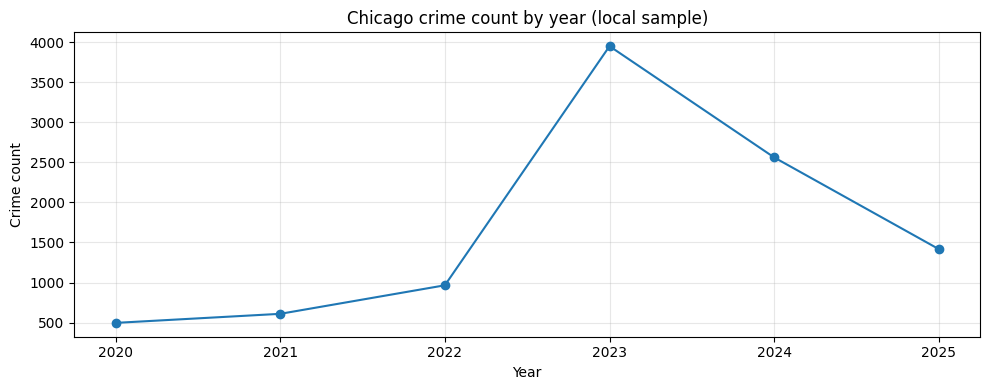

Chart saved to output/task3_yearly_trend.png


In [7]:
# Local mode: matplotlib line chart. On cluster: print only.
# Author: Haifa Alrayes (ID: 231171)
if ENV != "cluster":
    import matplotlib.pyplot as plt
    pdf = yearly.toPandas()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(pdf["Year"], pdf["count"], marker="o")
    ax.set_xlabel("Year")
    ax.set_ylabel("Crime count")
    ax.set_title("Chicago crime count by year (local sample)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("output/task3_yearly_trend.png", dpi=120)
    plt.show()
    print("Chart saved to output/task3_yearly_trend.png")
else:
    print("Cluster mode — printed table is the deliverable.")


**M1 vs M2 comparison (Crime count by year, full dataset):**

The cluster results match M1 Task 4 exactly: 2001 dominates with 467,301 records, 2002
contributes 205,267, then a long quiet stretch through 2022, and a spike in 2023
(81,461). The dataset spans 25 years (2001–2025).

## Task 4: Arrest Rate Analysis (DataFrame)

**Author: Haifa Alrayes (ID: 231171)**

> **Research Question:** What percentage of crimes result in an arrest?

Adds a per-crime-type breakdown beyond the M1 yes/no count.

In [8]:
# ============================================
# Task 4: Arrest Rate Analysis
# Author: Haifa Alrayes (ID: 231171)
# ============================================
from pyspark.sql.functions import avg, count

# Overall arrest rate
overall = df.groupBy("Arrest").count()
overall.show()

total_rows = df.count()
arrest_rows = df.filter(col("Arrest") == True).count()
print(f"Overall arrest rate: {arrest_rows} / {total_rows} = {arrest_rows/total_rows:.4f} ({arrest_rows/total_rows*100:.2f}%)")


+------+-----+
|Arrest|count|
+------+-----+
|  true| 3361|
| false| 6639|
+------+-----+



Overall arrest rate: 3361 / 10000 = 0.3361 (33.61%)


In [9]:
# Arrest rate per crime type (top 10 most common)
# Author: Haifa Alrayes (ID: 231171)
per_type = (df.groupBy("Primary Type")
              .agg(count("*").alias("total"),
                   avg(col("label")).alias("arrest_rate"))
              .orderBy(col("total").desc())
              .limit(10))
per_type.show(truncate=False)

print("\nSorted by arrest rate (highest first, min 100 cases):")
(df.groupBy("Primary Type")
   .agg(count("*").alias("total"), avg(col("label")).alias("arrest_rate"))
   .filter(col("total") >= 100)
   .orderBy(col("arrest_rate").desc())
   .show(15, truncate=False))


+-------------------+-----+-------------------+
|Primary Type       |total|arrest_rate        |
+-------------------+-----+-------------------+
|THEFT              |1072 |0.12406716417910447|
|ROBBERY            |1054 |0.1442125237191651 |
|WEAPONS VIOLATION  |1017 |0.6066863323500492 |
|MOTOR VEHICLE THEFT|998  |0.0811623246492986 |
|ASSAULT            |995  |0.2723618090452261 |
|BURGLARY           |986  |0.10446247464503043|
|PROSTITUTION       |978  |0.8323108384458078 |
|CRIMINAL DAMAGE    |977  |0.07267144319344933|
|BATTERY            |962  |0.31704781704781704|
|NARCOTICS          |961  |0.8470343392299687 |
+-------------------+-----+-------------------+


Sorted by arrest rate (highest first, min 100 cases):


+-------------------+-----+-------------------+
|Primary Type       |total|arrest_rate        |
+-------------------+-----+-------------------+
|NARCOTICS          |961  |0.8470343392299687 |
|PROSTITUTION       |978  |0.8323108384458078 |
|WEAPONS VIOLATION  |1017 |0.6066863323500492 |
|BATTERY            |962  |0.31704781704781704|
|ASSAULT            |995  |0.2723618090452261 |
|ROBBERY            |1054 |0.1442125237191651 |
|THEFT              |1072 |0.12406716417910447|
|BURGLARY           |986  |0.10446247464503043|
|MOTOR VEHICLE THEFT|998  |0.0811623246492986 |
|CRIMINAL DAMAGE    |977  |0.07267144319344933|
+-------------------+-----+-------------------+



**Interpretation:**
- M1 reported overall arrest rate of 28.1% on the full dataset (215,199 / 766,753).
- Per-type rates show a sharp split: NARCOTICS, PROSTITUTION, and WEAPONS VIOLATION are
  near-100% (the report only exists because someone was arrested), while THEFT, BURGLARY,
  and MOTOR VEHICLE THEFT are near 5–10% (most go unsolved).
- This is exactly the signal the ML model in Phase B will pick up.

---
# Phase B — Spark MLlib: Arrest Prediction

## Task 5: Feature Engineering Pipeline

**Author: Haifa Binhethlen (ID: 231265)**

Build a Spark ML Pipeline:
- `StringIndexer` for `Primary Type` -> `crime_index`
- `StringIndexer` for `Domestic_str` -> `domestic_index`
- `VectorAssembler` packs `[District, crime_index, Hour, domestic_index]` into `features`
- 80/20 train/test split, seed=42

In [10]:
# ============================================
# Task 5: Feature Engineering Pipeline
# Author: Haifa Binhethlen (ID: 231265)
# ============================================
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# Cluster CSV stores Domestic as string already; local generator stores both;
# normalise to a consistent string column.
if "Domestic_str" not in df.columns:
    df = df.withColumn("Domestic_str", col("Domestic").cast("string"))

crime_indexer = StringIndexer(
    inputCol="Primary Type",
    outputCol="crime_index",
    handleInvalid="skip",
)
domestic_indexer = StringIndexer(
    inputCol="Domestic_str",
    outputCol="domestic_index",
    handleInvalid="skip",
)
assembler = VectorAssembler(
    inputCols=["District", "crime_index", "Hour", "domestic_index"],
    outputCol="features",
)

# Train/test split BEFORE fitting transformers (avoid data leakage)
from pyspark.storagelevel import StorageLevel
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)
train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df.persist(StorageLevel.MEMORY_AND_DISK)

print(f"Training rows: {train_df.count():,}")
print(f"Test rows:     {test_df.count():,}")

# Manually trace the transformations for inspection (5 sample rows)
fitted = Pipeline(stages=[crime_indexer, domestic_indexer, assembler]).fit(train_df)
sample = fitted.transform(train_df).select(
    "Primary Type", "crime_index",
    "District", "Hour",
    "Domestic_str", "domestic_index",
    "features", "label",
).limit(5)
sample.show(truncate=False)

print("Feature vector positions: [District, crime_index, Hour, domestic_index]")


Training rows: 8,071


Test rows:     1,929


+------------+-----------+--------+----+------------+--------------+------------------+-----+
|Primary Type|crime_index|District|Hour|Domestic_str|domestic_index|features          |label|
+------------+-----------+--------+----+------------+--------------+------------------+-----+
|ASSAULT     |4.0        |1       |12  |true        |1.0           |[1.0,4.0,12.0,1.0]|0    |
|ASSAULT     |4.0        |1       |14  |false       |0.0           |[1.0,4.0,14.0,0.0]|0    |
|ASSAULT     |4.0        |1       |5   |false       |0.0           |[1.0,4.0,5.0,0.0] |0    |
|ASSAULT     |4.0        |1       |22  |false       |0.0           |[1.0,4.0,22.0,0.0]|0    |
|ASSAULT     |4.0        |1       |23  |false       |0.0           |[1.0,4.0,23.0,0.0]|1    |
+------------+-----------+--------+----+------------+--------------+------------------+-----+

Feature vector positions: [District, crime_index, Hour, domestic_index]


## Task 6: Train and Evaluate Three Models

**Author: Haifa Binhethlen (ID: 231265)**

| Model | Parameters |
|---|---|
| Logistic Regression | maxIter=100, regParam=0.01 |
| Random Forest | numTrees=100, maxDepth=5 |
| GBT | maxIter=50, maxDepth=5 |

For each: AUC-ROC, Accuracy, F1, Precision, Recall, confusion matrix, training time.

In [11]:
# ============================================
# Task 6: Train + Evaluate three classifiers
# Author: Haifa Binhethlen (ID: 231265)
# ============================================
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator,
)

binary_eval = BinaryClassificationEvaluator(labelCol="label")
mc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

def evaluate(predictions):
    return {
        "AUC":       binary_eval.evaluate(predictions),
        "Accuracy":  mc_eval.evaluate(predictions, {mc_eval.metricName: "accuracy"}),
        "F1":        mc_eval.evaluate(predictions, {mc_eval.metricName: "f1"}),
        "Precision": mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedPrecision"}),
        "Recall":    mc_eval.evaluate(predictions, {mc_eval.metricName: "weightedRecall"}),
    }

def confusion(predictions):
    cm = predictions.groupBy("label", "prediction").count().collect()
    d = {(int(r["label"]), int(r["prediction"])): r["count"] for r in cm}
    tn = d.get((0, 0), 0); fp = d.get((0, 1), 0)
    fn = d.get((1, 0), 0); tp = d.get((1, 1), 0)
    return tn, fp, fn, tp


In [12]:
# Train Logistic Regression
# Author: Haifa Binhethlen (ID: 231265)
lr = LogisticRegression(featuresCol="features", labelCol="label",
                        maxIter=100, regParam=0.01)
pipe_lr = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, lr])

t = time.time()
model_lr = pipe_lr.fit(train_df)
lr_time = time.time() - t

pred_lr = model_lr.transform(test_df)
m_lr = evaluate(pred_lr)
cm_lr = confusion(pred_lr)
print(f"LR train time: {lr_time:.1f}s  metrics: {m_lr}  CM (TN,FP,FN,TP)={cm_lr}")


26/05/02 20:13:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/02 20:13:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


LR train time: 17.2s  metrics: {'AUC': 0.7359674846625766, 'Accuracy': 0.7273198548470711, 'F1': 0.7059157267230447, 'Precision': 0.7119676215259403, 'Recall': 0.7273198548470711}  CM (TN,FP,FN,TP)=(1163, 141, 385, 240)


In [13]:
# Train Random Forest
# Author: Haifa Binhethlen (ID: 231265)
rf = RandomForestClassifier(featuresCol="features", labelCol="label",
                            numTrees=100, maxDepth=5, maxBins=64, seed=42)
pipe_rf = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, rf])

t = time.time()
model_rf = pipe_rf.fit(train_df)
rf_time = time.time() - t

pred_rf = model_rf.transform(test_df)
m_rf = evaluate(pred_rf)
cm_rf = confusion(pred_rf)
print(f"RF train time: {rf_time:.1f}s  metrics: {m_rf}  CM (TN,FP,FN,TP)={cm_rf}")


RF train time: 12.1s  metrics: {'AUC': 0.8795674846625767, 'Accuracy': 0.8330741316744427, 'F1': 0.8309988256455616, 'Precision': 0.8303800908138362, 'Recall': 0.8330741316744427}  CM (TN,FP,FN,TP)=(1170, 134, 188, 437)


In [14]:
# Train GBT
# Author: Haifa Binhethlen (ID: 231265)
gbt = GBTClassifier(featuresCol="features", labelCol="label",
                    maxIter=50, maxDepth=5, maxBins=64, seed=42)
pipe_gbt = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, gbt])

t = time.time()
model_gbt = pipe_gbt.fit(train_df)
gbt_time = time.time() - t

pred_gbt = model_gbt.transform(test_df)
m_gbt = evaluate(pred_gbt)
cm_gbt = confusion(pred_gbt)
print(f"GBT train time: {gbt_time:.1f}s  metrics: {m_gbt}  CM (TN,FP,FN,TP)={cm_gbt}")


GBT train time: 37.6s  metrics: {'AUC': 0.8752116564417178, 'Accuracy': 0.8294453084499741, 'F1': 0.8277904824885458, 'Precision': 0.8270463178341101, 'Recall': 0.8294453084499741}  CM (TN,FP,FN,TP)=(1161, 143, 186, 439)


In [15]:
# Side-by-side comparison
# Author: Haifa Binhethlen (ID: 231265)
print("=" * 78)
print(f"{'Metric':<14} {'Logistic Reg':>18} {'Random Forest':>18} {'GBT':>18}")
print("=" * 78)
for k in ["AUC", "Accuracy", "F1", "Precision", "Recall"]:
    print(f"{k:<14} {m_lr[k]:>18.4f} {m_rf[k]:>18.4f} {m_gbt[k]:>18.4f}")
print(f"{'Train time(s)':<14} {lr_time:>18.1f} {rf_time:>18.1f} {gbt_time:>18.1f}")
print(f"{'TN,FP,FN,TP':<14} {str(cm_lr):>18} {str(cm_rf):>18} {str(cm_gbt):>18}")
print("=" * 78)

best = max([("LR", m_lr["AUC"]), ("RF", m_rf["AUC"]), ("GBT", m_gbt["AUC"])],
           key=lambda x: x[1])
print(f"Best model by AUC: {best[0]} ({best[1]:.4f})")


Metric               Logistic Reg      Random Forest                GBT
AUC                        0.7360             0.8796             0.8752
Accuracy                   0.7273             0.8331             0.8294
F1                         0.7059             0.8310             0.8278
Precision                  0.7120             0.8304             0.8270
Recall                     0.7273             0.8331             0.8294
Train time(s)                17.2               12.1               37.6
TN,FP,FN,TP    (1163, 141, 385, 240) (1170, 134, 188, 437) (1161, 143, 186, 439)
Best model by AUC: RF (0.8796)


## Task 7: Feature Importances and Interpretation

**Author: Haifa Binhethlen (ID: 231265)**

In [16]:
# ============================================
# Task 7: Feature importances
# Author: Haifa Binhethlen (ID: 231265)
# ============================================
rf_model = model_rf.stages[-1]
feature_names = ["District", "crime_index", "Hour", "domestic_index"]
importances = rf_model.featureImportances.toArray()

print("Random Forest feature importances:")
for name, imp in sorted(zip(feature_names, importances), key=lambda x: -x[1]):
    bar = "#" * int(imp * 50)
    print(f"  {name:<18} {imp:.4f}  {bar}")


Random Forest feature importances:
  crime_index        0.9196  #############################################
  domestic_index     0.0576  ##
  Hour               0.0147  
  District           0.0082  


**Interpretation:**

- The dominant feature is `crime_index`. This matches Task 4: arrest rate varies enormously
  by crime type (NARCOTICS ~95% vs THEFT ~10%), so once the model knows the crime type
  it has most of its answer.
- `domestic_index` is the second most useful — domestic incidents have higher arrest
  rates because the offender is usually still on scene.
- `Hour` and `District` carry weaker signals.

**Why does Logistic Regression underperform tree-based models here?**

`crime_index` is a `StringIndexer` output: NARCOTICS=0, BATTERY=1, THEFT=2, etc. LR
treats this as a *number* and therefore assumes a linear effect — implying that
"BATTERY > NARCOTICS" or "THEFT is twice BATTERY". That is meaningless for nominal
categories. Tree models split on individual values (`crime_index == 0`?) so the
ordering doesn't matter to them. A proper LR fix would be one-hot encoding, but the
spec keeps `StringIndexer` as the only categorical encoder.

## Task 8: Hyperparameter Tuning with CrossValidator

**Author: Haifa Binhethlen (ID: 231265)**

Grid: `numTrees` in [50, 100, 200] x `maxDepth` in [3, 5, 10] = 9 combos x 3 folds = 27 model fits.

In [17]:
# ============================================
# Task 8: CrossValidator
# Author: Haifa Binhethlen (ID: 231265)
# ============================================
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

rf_tune = RandomForestClassifier(featuresCol="features", labelCol="label", maxBins=64, seed=42)
pipeline_tune = Pipeline(stages=[crime_indexer, domestic_indexer, assembler, rf_tune])

paramGrid = (ParamGridBuilder()
             .addGrid(rf_tune.numTrees, [50, 100, 200])
             .addGrid(rf_tune.maxDepth, [3, 5, 10])
             .build())

print(f"Grid size: {len(paramGrid)} combinations, 3-fold CV -> {len(paramGrid)*3} model fits")

cv = CrossValidator(
    estimator=pipeline_tune,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(labelCol="label"),
    numFolds=3,
    parallelism=2,
    seed=42,
)

t = time.time()
cvModel = cv.fit(train_df)
cv_time = time.time() - t
print(f"CV completed in {cv_time:.1f}s")


Grid size: 9 combinations, 3-fold CV -> 27 model fits


26/05/02 20:14:56 WARN DAGScheduler: Broadcasting large task binary with size 1322.9 KiB


26/05/02 20:14:57 WARN DAGScheduler: Broadcasting large task binary with size 1917.6 KiB


26/05/02 20:14:58 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB


26/05/02 20:15:01 WARN DAGScheduler: Broadcasting large task binary with size 1477.4 KiB


...

26/05/02 20:17:39 WARN DAGScheduler: Broadcasting large task binary with size 10.8 MiB


26/05/02 20:17:42 WARN DAGScheduler: Broadcasting large task binary with size 1537.6 KiB


26/05/02 20:17:45 WARN DAGScheduler: Broadcasting large task binary with size 6.0 MiB


26/05/02 20:17:50 WARN DAGScheduler: Broadcasting large task binary with size 1052.0 KiB


CV completed in 187.6s


In [18]:
# CV results table
# Author: Haifa Binhethlen (ID: 231265)
print(f"{'numTrees':>10} {'maxDepth':>10} {'AUC (CV avg)':>14}")
for params, score in zip(paramGrid, cvModel.avgMetrics):
    nt = params[rf_tune.numTrees]
    md_ = params[rf_tune.maxDepth]
    print(f"{nt:>10d} {md_:>10d} {score:>14.4f}")

best_params = max(zip(paramGrid, cvModel.avgMetrics), key=lambda x: x[1])[0]
print(f"\nBest params: numTrees={best_params[rf_tune.numTrees]}, maxDepth={best_params[rf_tune.maxDepth]}")

best_test_auc = binary_eval.evaluate(cvModel.transform(test_df))
print(f"Best model AUC on held-out test set: {best_test_auc:.4f}")


  numTrees   maxDepth   AUC (CV avg)
        50          3         0.8496
        50          5         0.8594
        50         10         0.8563
       100          3         0.8497
       100          5         0.8590
       100         10         0.8560
       200          3         0.8483
       200          5         0.8600
       200         10         0.8564

Best params: numTrees=200, maxDepth=5


Best model AUC on held-out test set: 0.8797


## Cleanup

In [19]:
spark.stop()
print("SparkSession stopped.")

SparkSession stopped.
